In [83]:
import pickle
import numpy as np
import pandas as pd
import os
import re

import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable

from nsga_population import *
from typing import List
from individual import Individual

log_base = "..\\logdata_2\\"
experiment_folders = ["Experiment_2_2025-02-12_14_33_01_231336", "Experiment_2_2025-02-13_00_09_58_200986", "Experiment_2_2025-02-13_01_13_16_488466"] #["Experiment_1_2024-09-27_classical_1", "Experiment_1_2024-09-30_12_05_58_215187", "Experiment_1_2024-09-30_13_51_09_109136", "Experiment_1_2024-09-30_15_31_13_949606"]
subfolder_name = "pareto_front_ft20_quantum_hash_base_encoding_0\\pareto_front.pkl"

In [84]:
def import_pareto_front(log_base, experiment_folders, subfolder_name):
    file_path = os.path.join(os.path.join(log_base, experiment_folders), subfolder_name)

    with open(file_path, "rb") as read_pop_dump:
        cur_pop = pickle.load(read_pop_dump)

    X = []
    Y = []
    for individual in cur_pop:
        x, y = individual.cur_fitness
        add_individual = True
        for i in range(len(X)):
            if x == X[i] and y == Y[i]:
                add_individual = False
        if add_individual:
            X.append(x)
            Y.append(y)

    front_array = np.array([X, Y])
    working_index = np.argmin(front_array[0])
    result_list = np.empty_like(front_array)
    front_array = front_array.tolist()

    for i in range(len(X)):
        result_list[0, i] = front_array[0].pop(working_index)
        result_list[1, i] = front_array[1].pop(working_index)
        # Calculate distance to other points to find next index
        min_distance = None
        for j in range(len(front_array[0])):
            cur_distance = np.sqrt(np.sum((result_list[:, i] - np.array([front_array[0][j], front_array[1][j]]))**2))
            if not min_distance or min_distance > cur_distance:
                working_index = j
                min_distance = cur_distance
            
    return result_list

    

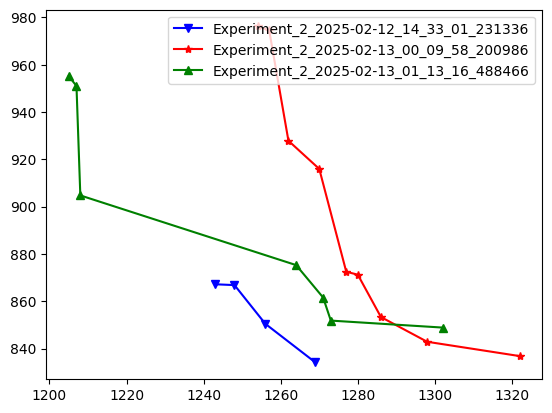

In [86]:
style_list = [("v", "b"), ("*", "r"), ("^", "green")]
for i, experiment in enumerate(experiment_folders):
    result_list = import_pareto_front(log_base, experiment, subfolder_name)
    plt.plot(result_list[0, :], result_list[1, :], marker=style_list[i][0], c=style_list[i][1], label=experiment)

plt.legend()
plt.show()